In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

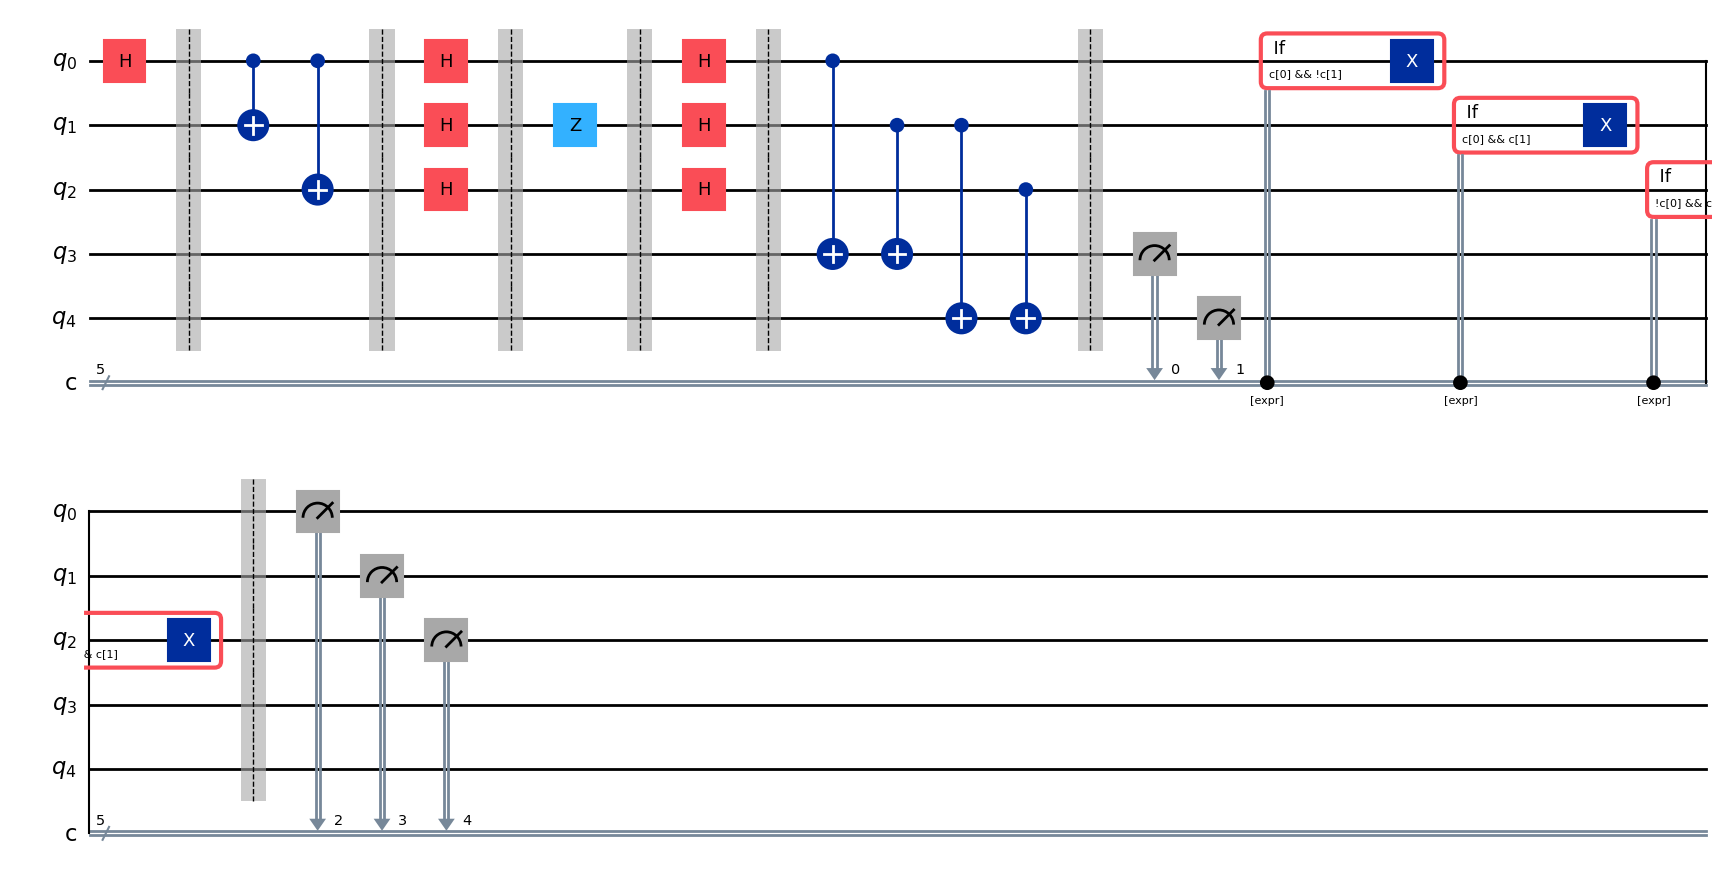

In [17]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.


flip = QuantumCircuit(5, 5)

# 1. Prepare state (must be in X-basis)
flip.h(0)

flip.barrier()

# 2. Encode (same repetition structure)
flip.cx(0, 1)
flip.cx(0, 2)

flip.barrier()

# ============================================================
# 3. MOVE TO X BASIS (CRITICAL STEP)
# This is what converts phase errors into bit errors
# ============================================================

flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# ============================================================
# 4. Introduce PHASE error (NOT X error)
# ============================================================

flip.z(1)

flip.barrier()

# ============================================================
# 5. MOVE BACK TO COMPUTATIONAL BASIS
# so syndrome detection works as bit-flip detection
# ============================================================

flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# ============================================================
# 6. Syndrome extraction (same as bit-flip code now works)
# ============================================================

flip.cx(0, 3)
flip.cx(1, 3)

flip.cx(1, 4)
flip.cx(2, 4)

flip.barrier()

# 7. Measure syndrome
flip.measure([3, 4], [0, 1])

# ============================================================
# 8. Conditional correction (X corrections are correct here)
# ============================================================

with flip.if_test(
    expr.logic_and(
        flip.clbits[0],
        expr.logic_not(flip.clbits[1])
    )
):
    flip.x(0)

with flip.if_test(
    expr.logic_and(
        flip.clbits[0],
        flip.clbits[1]
    )
):
    flip.x(1)

with flip.if_test(
    expr.logic_and(
        expr.logic_not(flip.clbits[0]),
        flip.clbits[1]
    )
):
    flip.x(2)

flip.barrier()

# ============================================================
# 9. Final measurement
# ============================================================

flip.measure([0, 1, 2], [2, 3, 4])

flip.draw("mpl")

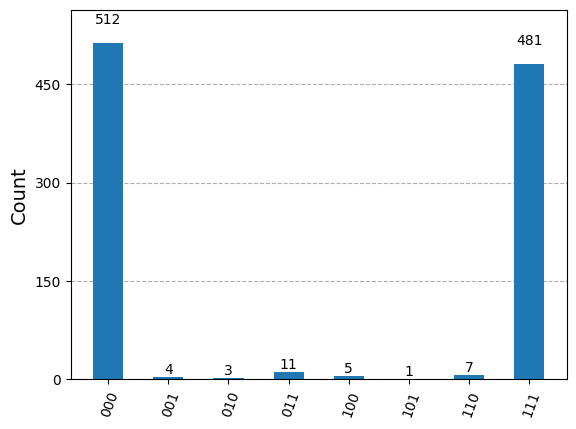

In [18]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)